# Seasonal Agriculture Performance Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('/content/seasonal_agriculture_performance_dataset.csv')
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [3]:
print(df.shape)

(4000, 28)


In [4]:
print(df.columns.tolist())

['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [6]:
print(df.isnull().sum())

Farm_ID                           0
State                             0
District                          0
Crop                              0
Season                            0
Farm_Area_Hectares                0
Rainfall_mm                      48
Avg_Temperature_C                 0
Humidity_pct                      0
Sunlight_Hours_Day                0
Soil_pH                           0
Soil_Moisture_pct                40
Nitrogen_kg_ha                    0
Phosphorus_kg_ha                  0
Potassium_kg_ha                   0
Irrigation_Method                 0
Fertilizer_kg_ha                  0
Pesticide_Litre_ha                0
Seed_Quality_Score                0
Yield_Tonnes_Ha                  32
Production_Tonnes                 0
Market_Price_INR_Tonne            0
Total_Cost_INR                    0
Revenue_INR                       0
Profit_INR                        0
Water_Used_m3                     0
Water_Efficiency_t_per_1000m3     0
Disease_Pest_Risk_pct       

In [7]:
df['Rainfall_mm'] = df['Rainfall_mm'].fillna(df['Rainfall_mm'].median())
df['Soil_Moisture_pct'] = df['Soil_Moisture_pct'].fillna(df['Soil_Moisture_pct'].median())
df['Yield_Tonnes_Ha'] = df['Yield_Tonnes_Ha'].fillna(df['Yield_Tonnes_Ha'].median())
print("Total missing values after cleaning:", df.isnull().sum().sum())
print("Dataset shape after cleaning:", df.shape)

Total missing values after cleaning: 0
Dataset shape after cleaning: (4000, 28)


In [8]:
print(df.describe())

       Farm_Area_Hectares  Rainfall_mm  Avg_Temperature_C  Humidity_pct  \
count         4000.000000  4000.000000         4000.00000   4000.000000   
mean             7.888265   600.922825           26.81890     63.210500   
std              4.223764   287.193381            3.81818     11.960834   
min              0.500000    80.000000           16.20000     25.000000   
25%              4.260000   371.575000           23.90000     54.775000   
50%              7.895000   582.000000           26.90000     63.000000   
75%             11.650000   831.975000           29.60000     71.900000   
max             15.000000  1395.200000           39.70000     95.000000   

       Sunlight_Hours_Day      Soil_pH  Soil_Moisture_pct  Nitrogen_kg_ha  \
count         4000.000000  4000.000000        4000.000000     4000.000000   
mean             7.323050     6.701010          26.507150      120.250825   
std              1.121186     0.641461           6.678837       31.216452   
min             

In [9]:
print("Number of duplicated rows",df.duplicated().sum())

Number of duplicated rows 0


In [10]:
print("States:",df['State'].nunique())
print("Districts:",df['District'].nunique())
print("Crop:",df['Crop'].nunique())
print("Season:",df['Season'].nunique())
print("Irrigation Methods:",df['Irrigation_Method'].nunique())

States: 8
Districts: 10
Crop: 8
Season: 3
Irrigation Methods: 4


In [11]:
print("Seasons available:",df['Season'].unique())
print("Crops available:",df['Crop'].unique())
print("Irrigation Methods:",df['Irrigation_Method'].unique())

Seasons available: ['Kharif' 'Rabi' 'Zaid']
Crops available: ['Wheat' 'Maize' 'Pulses' 'Rice' 'Cotton' 'Chilli' 'Groundnut' 'Sugarcane']
Irrigation Methods: ['Drip' 'Flood' 'Rainfed' 'Sprinkler']


In [12]:
season_count=df['Season'].value_counts()
print(season_count)

Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64


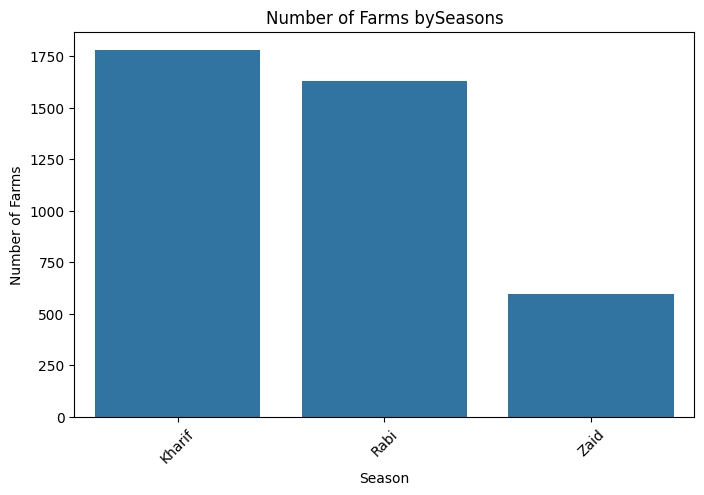

In [13]:
plt.figure(figsize=(8,5))
sns.countplot(x='Season',data=df)
plt.title('Number of Farms by Seasons')
plt.xlabel('Season')
plt.ylabel('Number of Farms')
plt.xticks(rotation=45)
plt.show()

In [14]:
season_summary=df.groupby('Season').agg({'Yield_Tonnes_Ha':'mean','Production_Tonnes':'mean','Revenue_INR':'mean','Profit_INR':'mean',
                                         'Water_Used_m3':'mean','Water_Efficiency_t_per_1000m3':'mean',}).round(2)
print(season_summary)

        Yield_Tonnes_Ha  Production_Tonnes  Revenue_INR  Profit_INR  \
Season                                                                
Kharif             5.63              46.31    710719.06   178914.65   
Rabi               5.04              41.49    601526.05    87689.47   
Zaid               4.64              38.89    519171.90   -24804.82   

        Water_Used_m3  Water_Efficiency_t_per_1000m3  
Season                                                
Kharif        6102.20                           5.89  
Rabi          5846.99                           5.19  
Zaid          6419.89                           4.41  


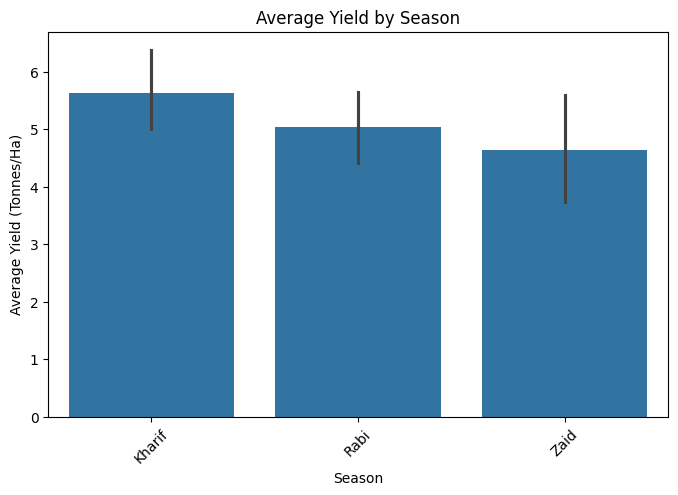

In [15]:
plt.figure(figsize=(8,5))
sns.barplot(x='Season',y='Yield_Tonnes_Ha',data=df,estimator='mean')
plt.title('Average Yield by Season')
plt.xlabel('Season')
plt.ylabel('Average Yield (Tonnes/Ha)')
plt.xticks(rotation=45)
plt.show()

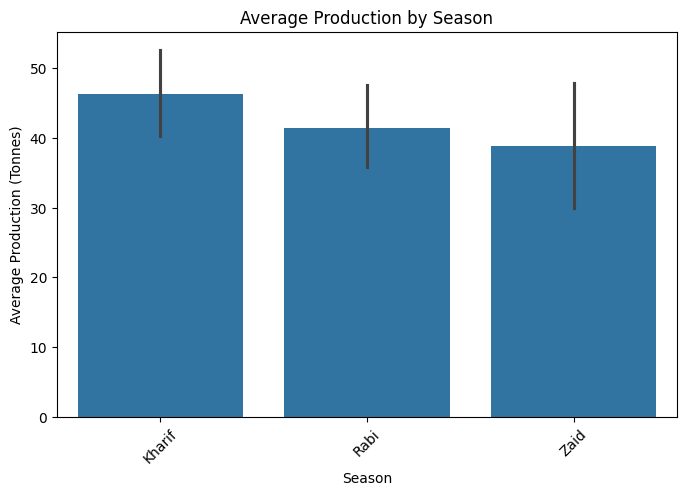

In [16]:
plt.figure(figsize=(8,5))
sns.barplot(x='Season',y='Production_Tonnes',data=df,estimator='mean')
plt.title('Average Production by Season')
plt.xlabel('Season')
plt.ylabel('Average Production (Tonnes)')
plt.xticks(rotation=45)
plt.show()

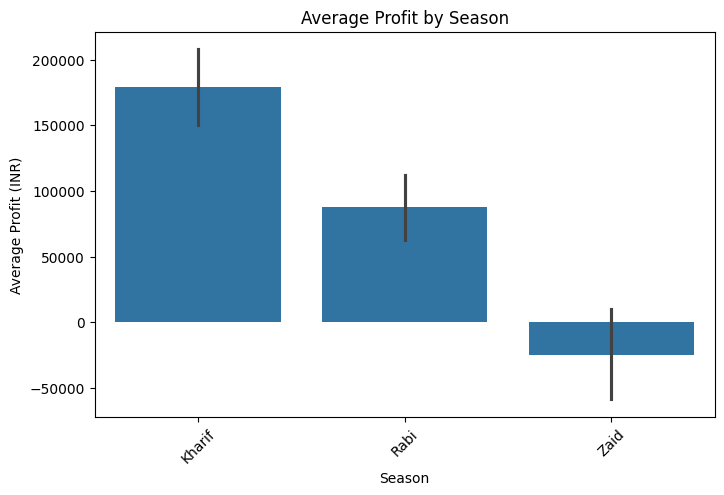

In [17]:
plt.figure(figsize=(8,5))
sns.barplot(x='Season',y='Profit_INR',data=df,estimator='mean')
plt.title('Average Profit by Season')
plt.xlabel('Season')
plt.ylabel('Average Profit (INR)')
plt.xticks(rotation=45)
plt.show()

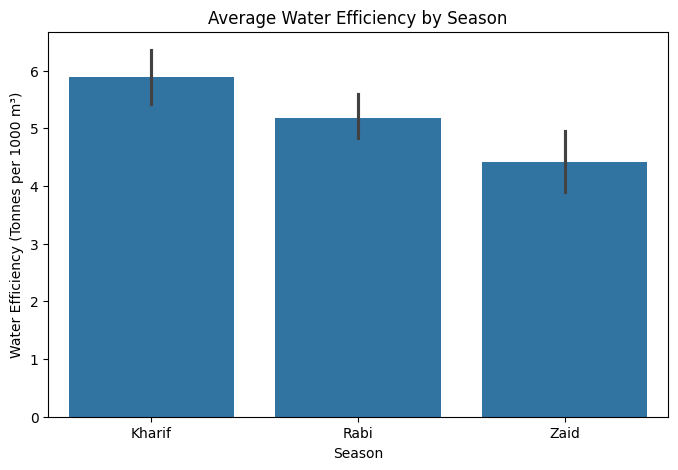

In [18]:
plt.figure(figsize=(8,5))
sns.barplot(data=df,x='Season',y='Water_Efficiency_t_per_1000m3',estimator='mean')
plt.title('Average Water Efficiency by Season')
plt.xlabel('Season')
plt.ylabel('Water Efficiency (Tonnes per 1000 m³)')
plt.show()

In [19]:
environment_summary = df.groupby('Season').agg({
    'Rainfall_mm': 'mean','Avg_Temperature_C': 'mean',
    'Humidity_pct': 'mean','Sunlight_Hours_Day': 'mean',
    'Soil_pH': 'mean','Soil_Moisture_pct': 'mean'
}).round(2)
print(environment_summary)

        Rainfall_mm  Avg_Temperature_C  Humidity_pct  Sunlight_Hours_Day  \
Season                                                                     
Kharif       849.20              28.45         71.81                6.79   
Rabi         437.62              23.49         57.89                7.59   
Zaid         304.65              31.04         52.01                8.18   

        Soil_pH  Soil_Moisture_pct  
Season                              
Kharif     6.73              31.15  
Rabi       6.67              24.07  
Zaid       6.69              19.28  


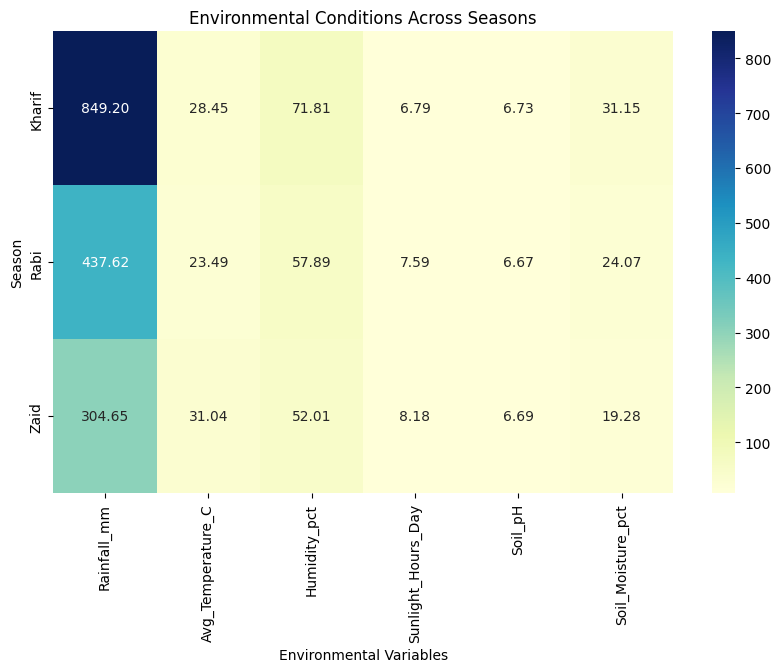

In [20]:
plt.figure(figsize=(10, 6))
sns.heatmap(environment_summary,annot=True,fmt='.2f',cmap='YlGnBu')
plt.title('Environmental Conditions Across Seasons')
plt.xlabel('Environmental Variables')
plt.ylabel('Season')
plt.show()

In [21]:
resource_summary = df.groupby('Season').agg({
    'Nitrogen_kg_ha': 'mean','Phosphorus_kg_ha': 'mean',
    'Potassium_kg_ha': 'mean','Fertilizer_kg_ha': 'mean',
    'Pesticide_Litre_ha': 'mean','Water_Used_m3': 'mean',
    'Disease_Pest_Risk_pct': 'mean'
}).round(2)
display(resource_summary)

,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Water_Used_m3,Disease_Pest_Risk_pct
Season,,,,,,,
Kharif,120.02,58.10,105.30,187.08,5.08,6102.20,54.47
Rabi,120.40,57.31,103.93,185.41,5.02,5846.99,40.48
Zaid,120.53,58.13,105.42,184.64,5.17,6419.89,38.22


In [22]:
irrigation_summary = df.groupby('Irrigation_Method').agg({
    'Yield_Tonnes_Ha': 'mean',
    'Profit_INR': 'mean',
    'Water_Used_m3': 'mean',
    'Water_Efficiency_t_per_1000m3': 'mean'
}).round(2)

display(irrigation_summary)

,Yield_Tonnes_Ha,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3
Irrigation_Method,,,,
Drip,6.58,219626.00,5918.75,6.27
Flood,4.86,73354.02,8026.47,3.44
Rainfed,4.60,79050.37,3549.55,7.56
Sprinkler,5.16,91121.08,6208.26,4.67


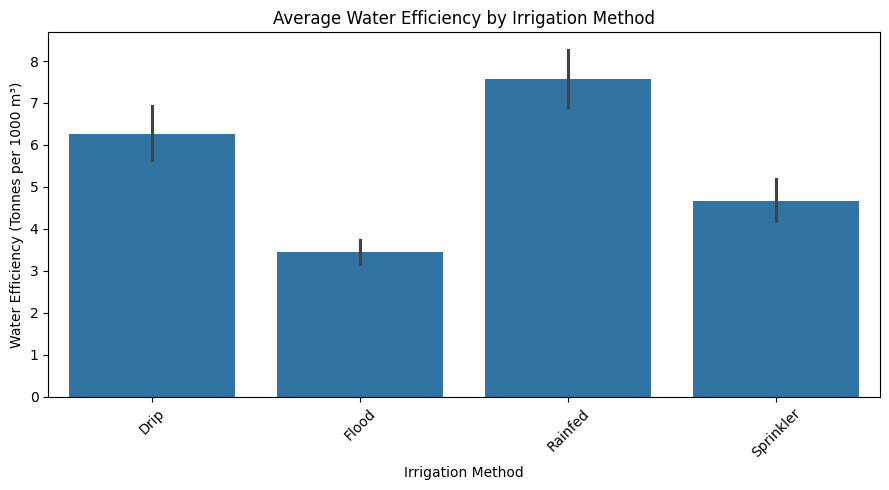

In [23]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=df,
    x='Irrigation_Method',
    y='Water_Efficiency_t_per_1000m3',
    estimator='mean'
)

plt.title('Average Water Efficiency by Irrigation Method')
plt.xlabel('Irrigation Method')
plt.ylabel('Water Efficiency (Tonnes per 1000 m³)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [24]:
economic_summary = df.groupby('Season').agg({
    'Market_Price_INR_Tonne': 'mean','Total_Cost_INR': 'mean',
    'Revenue_INR': 'mean','Profit_INR': 'mean'
}).round(2)
display(economic_summary)

,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR
Season,,,,
Kharif,44850.91,531804.41,710719.06,178914.65
Rabi,44747.97,513836.58,601526.05,87689.47
Zaid,44212.03,543976.73,519171.90,-24804.82


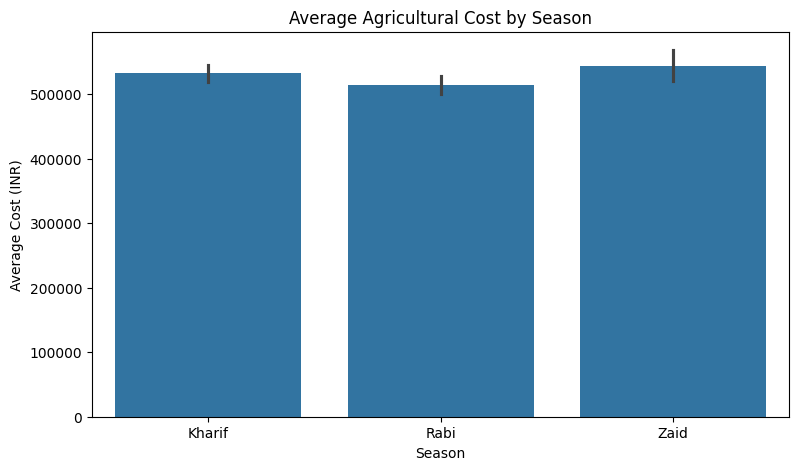

In [25]:
plt.figure(figsize=(9, 5))
sns.barplot(data=df,x='Season',y='Total_Cost_INR',estimator='mean')
plt.title('Average Agricultural Cost by Season')
plt.xlabel('Season')
plt.ylabel('Average Cost (INR)')
plt.show()

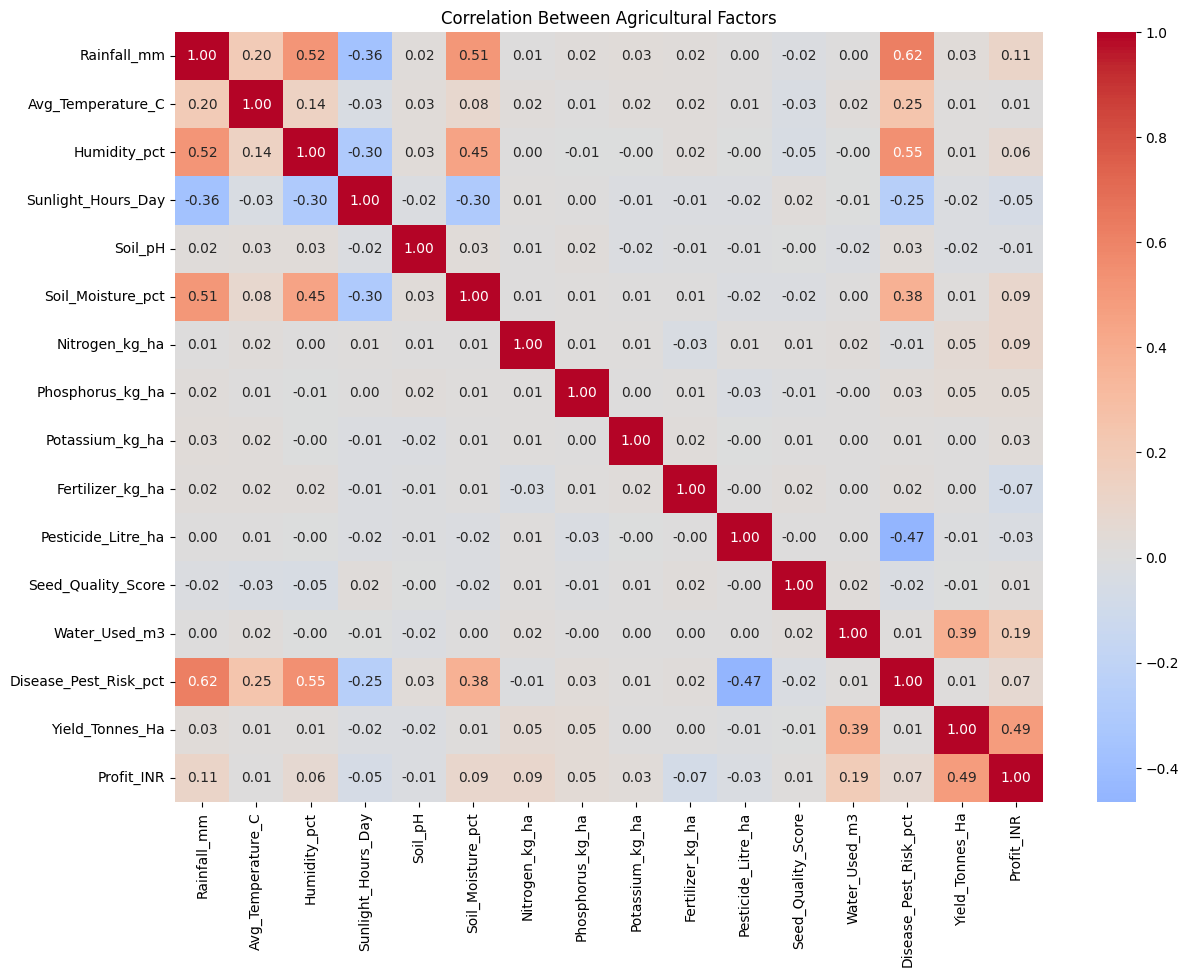

In [26]:
correlation_columns = [
    'Rainfall_mm','Avg_Temperature_C','Humidity_pct',
    'Sunlight_Hours_Day','Soil_pH','Soil_Moisture_pct',
    'Nitrogen_kg_ha','Phosphorus_kg_ha','Potassium_kg_ha','Fertilizer_kg_ha',
    'Pesticide_Litre_ha','Seed_Quality_Score','Water_Used_m3',
    'Disease_Pest_Risk_pct','Yield_Tonnes_Ha','Profit_INR'
]
correlation_matrix = df[correlation_columns].corr()
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix,annot=True,fmt='.2f',cmap='coolwarm',center=0)
plt.title('Correlation Between Agricultural Factors')
plt.show()

In [27]:
yield_corr = correlation_matrix['Yield_Tonnes_Ha'].sort_values(ascending=False)
print(yield_corr)

Yield_Tonnes_Ha          1.000000
Profit_INR               0.488466
Water_Used_m3            0.386294
Nitrogen_kg_ha           0.053149
Phosphorus_kg_ha         0.047941
Rainfall_mm              0.030951
Disease_Pest_Risk_pct    0.014292
Humidity_pct             0.012297
Soil_Moisture_pct        0.010999
Avg_Temperature_C        0.009996
Potassium_kg_ha          0.003382
Fertilizer_kg_ha         0.000018
Seed_Quality_Score      -0.007209
Pesticide_Litre_ha      -0.007779
Sunlight_Hours_Day      -0.015341
Soil_pH                 -0.020672
Name: Yield_Tonnes_Ha, dtype: float64


In [28]:
profit_corr = correlation_matrix['Profit_INR'].sort_values(ascending=False)
print(profit_corr)

Profit_INR               1.000000
Yield_Tonnes_Ha          0.488466
Water_Used_m3            0.190278
Rainfall_mm              0.107648
Soil_Moisture_pct        0.091281
Nitrogen_kg_ha           0.085016
Disease_Pest_Risk_pct    0.067583
Humidity_pct             0.063775
Phosphorus_kg_ha         0.049747
Potassium_kg_ha          0.031192
Seed_Quality_Score       0.010438
Avg_Temperature_C        0.009043
Soil_pH                 -0.013145
Pesticide_Litre_ha      -0.025705
Sunlight_Hours_Day      -0.054822
Fertilizer_kg_ha        -0.073542
Name: Profit_INR, dtype: float64


In [29]:
from scipy.stats import f_oneway
kharif_yield = df[df['Season'] == 'Kharif']['Yield_Tonnes_Ha'].dropna()
rabi_yield = df[df['Season'] == 'Rabi']['Yield_Tonnes_Ha'].dropna()
zaid_yield = df[df['Season'] == 'Zaid']['Yield_Tonnes_Ha'].dropna()
f_stat_yield, p_value_yield = f_oneway(kharif_yield,rabi_yield,zaid_yield)
print("ANOVA Test - Yield")
print("F-statistic:", round(f_stat_yield, 4))
print("p-value:", p_value_yield)
if p_value_yield < 0.05:
    print("Result: Significant difference in yield across seasons.")
else:
    print("Result: No statistically significant difference in yield across seasons.")

ANOVA Test - Yield
F-statistic: 1.5439
p-value: 0.21367813841792296
Result: No statistically significant difference in yield across seasons.


In [30]:
kharif_profit = df[df['Season'] == 'Kharif']['Profit_INR']
rabi_profit = df[df['Season'] == 'Rabi']['Profit_INR']
zaid_profit = df[df['Season'] == 'Zaid']['Profit_INR']
f_stat_profit, p_value_profit = f_oneway(kharif_profit,rabi_profit,zaid_profit)
print("ANOVA Test - Profit")
print("F-statistic:", round(f_stat_profit, 4))
print("p-value:", round(p_value_profit, 6))
if p_value_profit < 0.05:
    print("Result: Significant difference in profit across seasons.")
else:
    print("Result: No statistically significant difference in profit across seasons.")

ANOVA Test - Profit
F-statistic: 34.2918
p-value: 0.0
Result: Significant difference in profit across seasons.


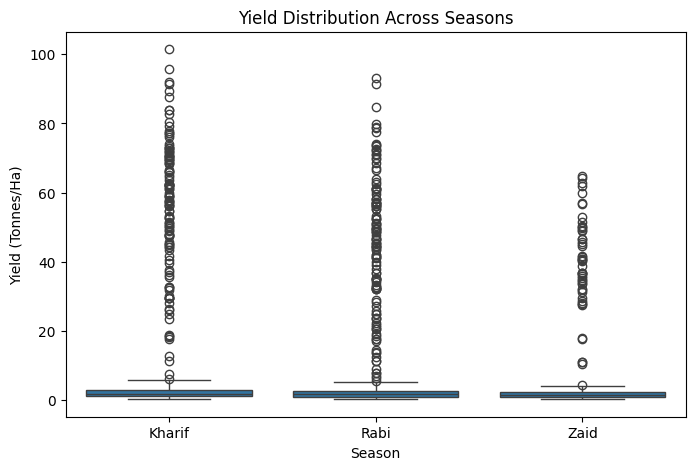

In [31]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df,x='Season',y='Yield_Tonnes_Ha')
plt.title('Yield Distribution Across Seasons')
plt.xlabel('Season')
plt.ylabel('Yield (Tonnes/Ha)')
plt.show()

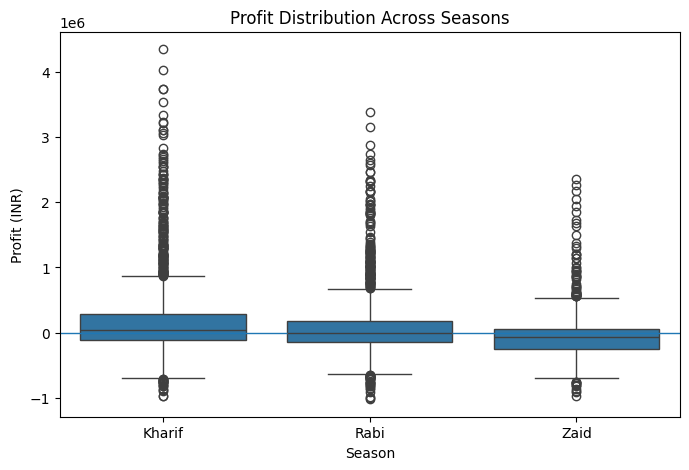

In [32]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df,x='Season',y='Profit_INR')
plt.title('Profit Distribution Across Seasons')
plt.xlabel('Season')
plt.ylabel('Profit (INR)')
plt.axhline(0, linewidth=1)
plt.show()

In [33]:
crop_season = df.groupby(['Crop', 'Season']).agg({'Yield_Tonnes_Ha': 'mean',
                  'Production_Tonnes': 'mean','Profit_INR': 'mean'}).round(2)
print(crop_season)

                  Yield_Tonnes_Ha  Production_Tonnes  Profit_INR
Crop      Season                                                
Chilli    Kharif             1.73              14.46   954380.42
          Rabi               1.47              10.97   638572.50
          Zaid               1.20               9.98   448659.09
Cotton    Kharif             1.37              10.41   216999.55
          Rabi               1.20               9.44   107343.59
          Zaid               0.96               6.93   -53925.34
Groundnut Kharif             1.48              10.49   108265.44
          Rabi               1.23               9.06    10416.54
          Zaid               1.04               8.62   -68872.50
Maize     Kharif             2.97              23.35   -39332.67
          Rabi               2.60              21.59   -89133.40
          Zaid               2.29              17.94  -194049.17
Pulses    Kharif             1.04               8.29    43338.90
          Rabi           

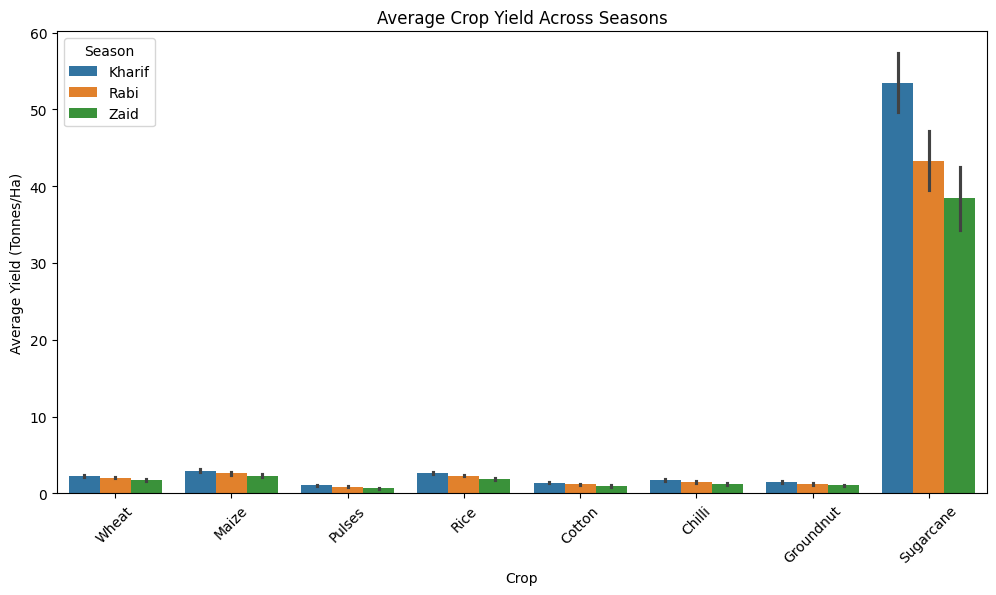

In [34]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df,x='Crop',y='Yield_Tonnes_Ha',hue='Season',estimator='mean')
plt.title('Average Crop Yield Across Seasons')
plt.xlabel('Crop')
plt.ylabel('Average Yield (Tonnes/Ha)')
plt.xticks(rotation=45)
plt.legend(title='Season')
plt.show()

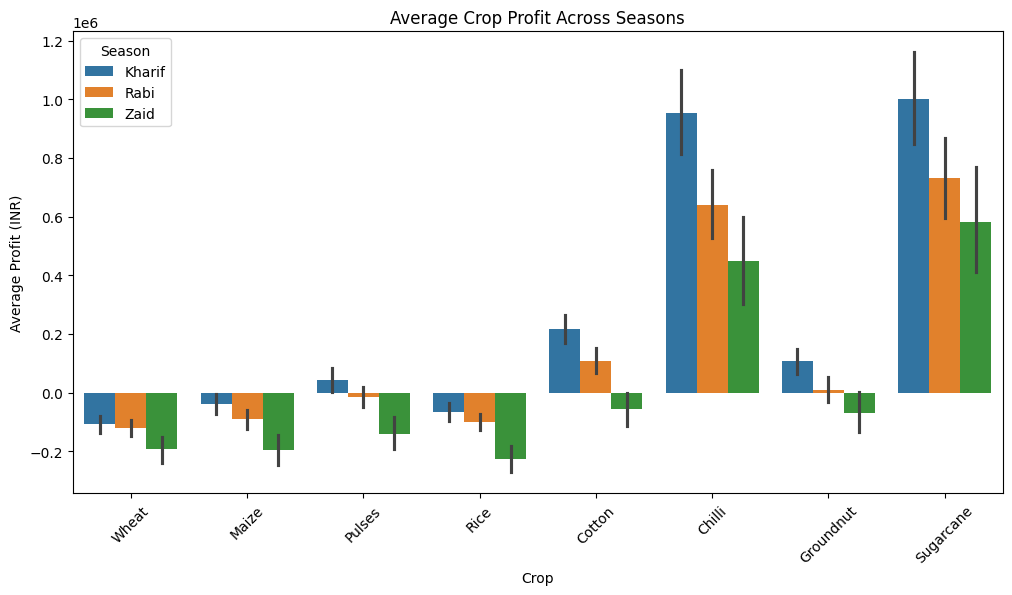

In [35]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df,x='Crop',y='Profit_INR',hue='Season',estimator='mean')
plt.title('Average Crop Profit Across Seasons')
plt.xlabel('Crop')
plt.ylabel('Average Profit (INR)')
plt.xticks(rotation=45)
plt.legend(title='Season')
plt.show()

In [36]:
state_summary = df.groupby('State').agg({'Yield_Tonnes_Ha': 'mean', 'Production_Tonnes': 'mean',
    'Revenue_INR': 'mean','Profit_INR': 'mean','Water_Used_m3': 'mean',
    'Water_Efficiency_t_per_1000m3': 'mean'}).round(2)
print(state_summary)

                Yield_Tonnes_Ha  Production_Tonnes  Revenue_INR  Profit_INR  \
State                                                                         
Andhra Pradesh             4.63              36.91    606663.66    73453.53   
Gujarat                    5.66              48.33    654692.86   117568.24   
Karnataka                  5.69              47.73    653426.18   119422.34   
Madhya Pradesh             4.99              37.56    597558.36    86840.76   
Maharashtra                5.02              43.98    650032.67   135428.86   
Punjab                     6.12              52.23    686225.70   136025.64   
Tamil Nadu                 4.88              40.84    629093.42   117744.75   
Telangana                  5.04              39.25    628784.53   108829.62   

                Water_Used_m3  Water_Efficiency_t_per_1000m3  
State                                                         
Andhra Pradesh        6058.38                           5.03  
Gujarat             

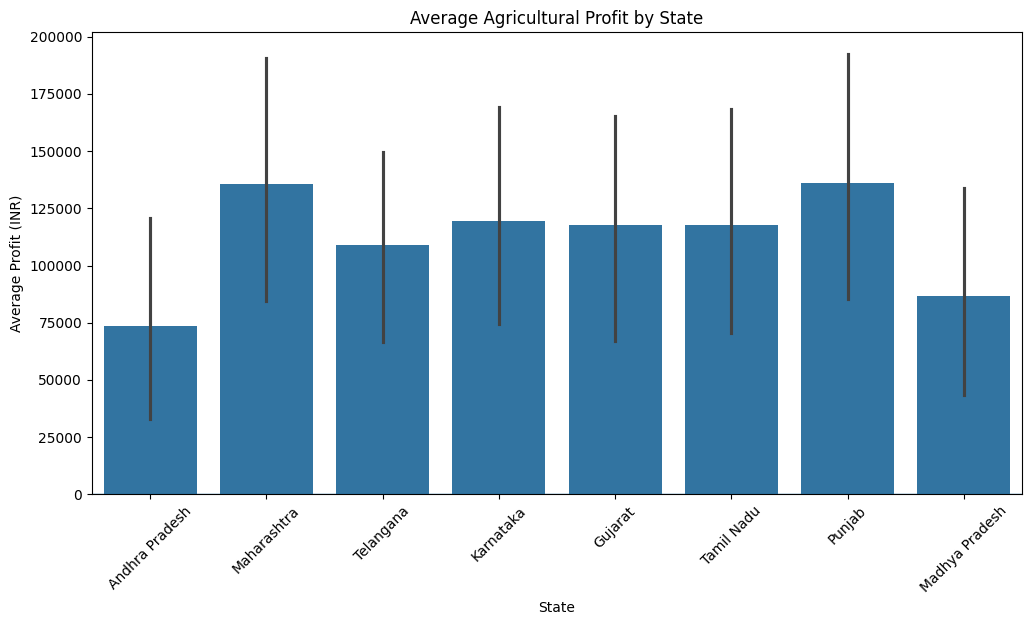

In [37]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df,x='State',y='Profit_INR',estimator='mean')
plt.title('Average Agricultural Profit by State')
plt.xlabel('State')
plt.ylabel('Average Profit (INR)')
plt.xticks(rotation=45)
plt.axhline(0, linewidth=1)
plt.show()

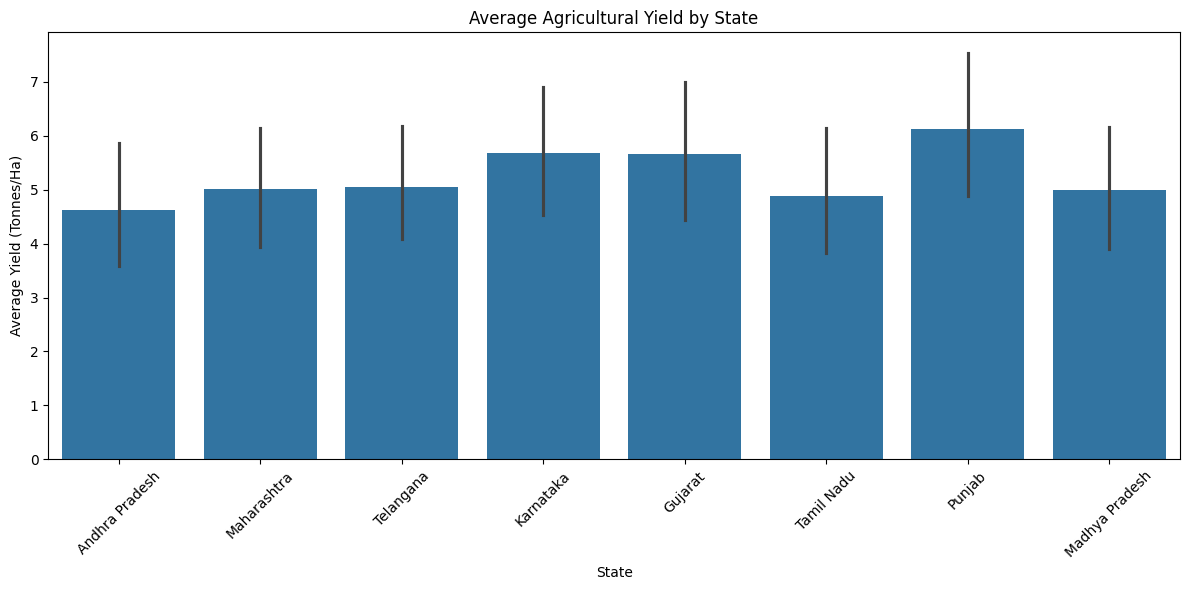

In [38]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df,x='State',y='Yield_Tonnes_Ha',estimator='mean')
plt.title('Average Agricultural Yield by State')
plt.xlabel('State')
plt.ylabel('Average Yield (Tonnes/Ha)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [39]:
state_season = df.groupby(['State', 'Season']).agg({'Yield_Tonnes_Ha': 'mean',
    'Profit_INR': 'mean','Water_Efficiency_t_per_1000m3': 'mean'}).round(2)
print(state_season)

                       Yield_Tonnes_Ha  Profit_INR  \
State          Season                                
Andhra Pradesh Kharif             5.68   169315.52   
               Rabi               3.47    26315.71   
               Zaid               4.45   -84084.87   
Gujarat        Kharif             6.34   217051.33   
               Rabi               5.44    82846.20   
               Zaid               4.07  -106929.61   
Karnataka      Kharif             6.46   201226.21   
               Rabi               4.57    70952.61   
               Zaid               6.62    23310.91   
Madhya Pradesh Kharif             5.99   134242.40   
               Rabi               3.76    61576.26   
               Zaid               5.48      209.70   
Maharashtra    Kharif             5.43   168801.05   
               Rabi               5.50   159581.50   
               Zaid               2.28   -40597.60   
Punjab         Kharif             4.10   133779.10   
               Rabi         

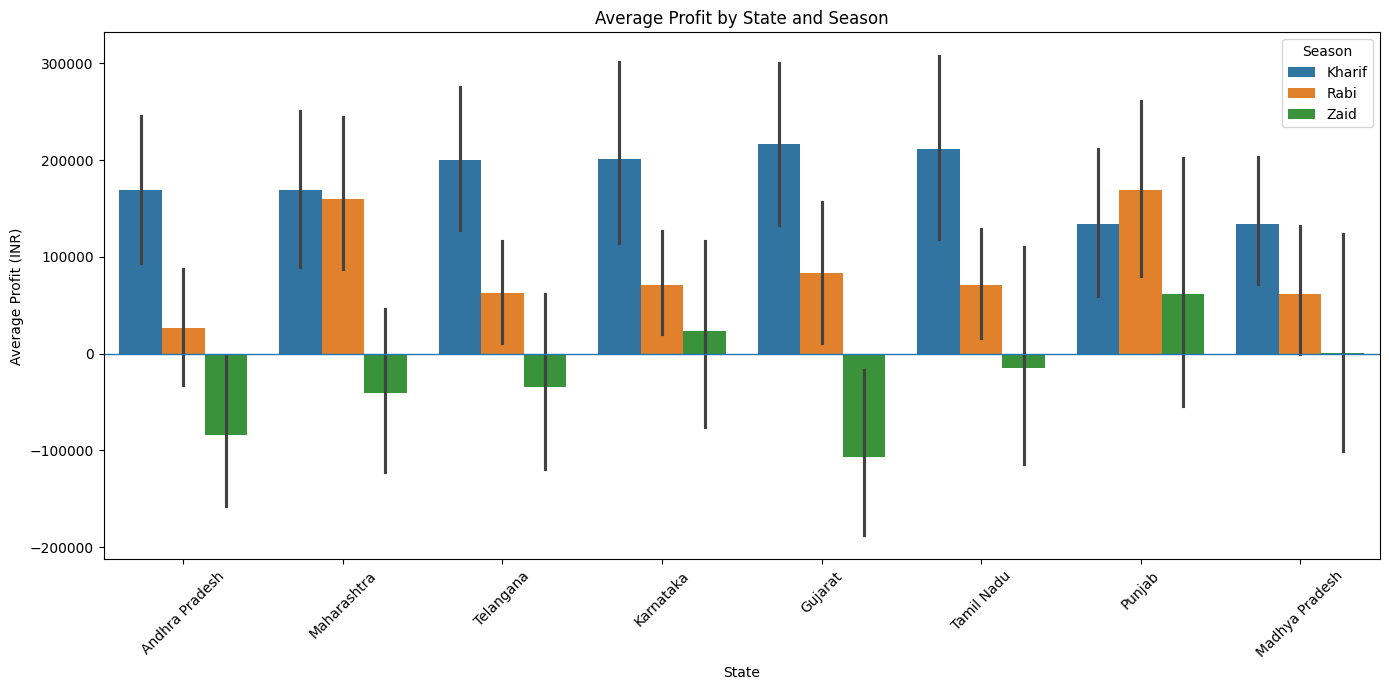

In [40]:
plt.figure(figsize=(14, 7))
sns.barplot(data=df,x='State',y='Profit_INR',hue='Season',estimator='mean')
plt.title('Average Profit by State and Season')
plt.xlabel('State')
plt.ylabel('Average Profit (INR)')
plt.xticks(rotation=45)
plt.axhline(0, linewidth=1)
plt.legend(title='Season')
plt.tight_layout()
plt.show()

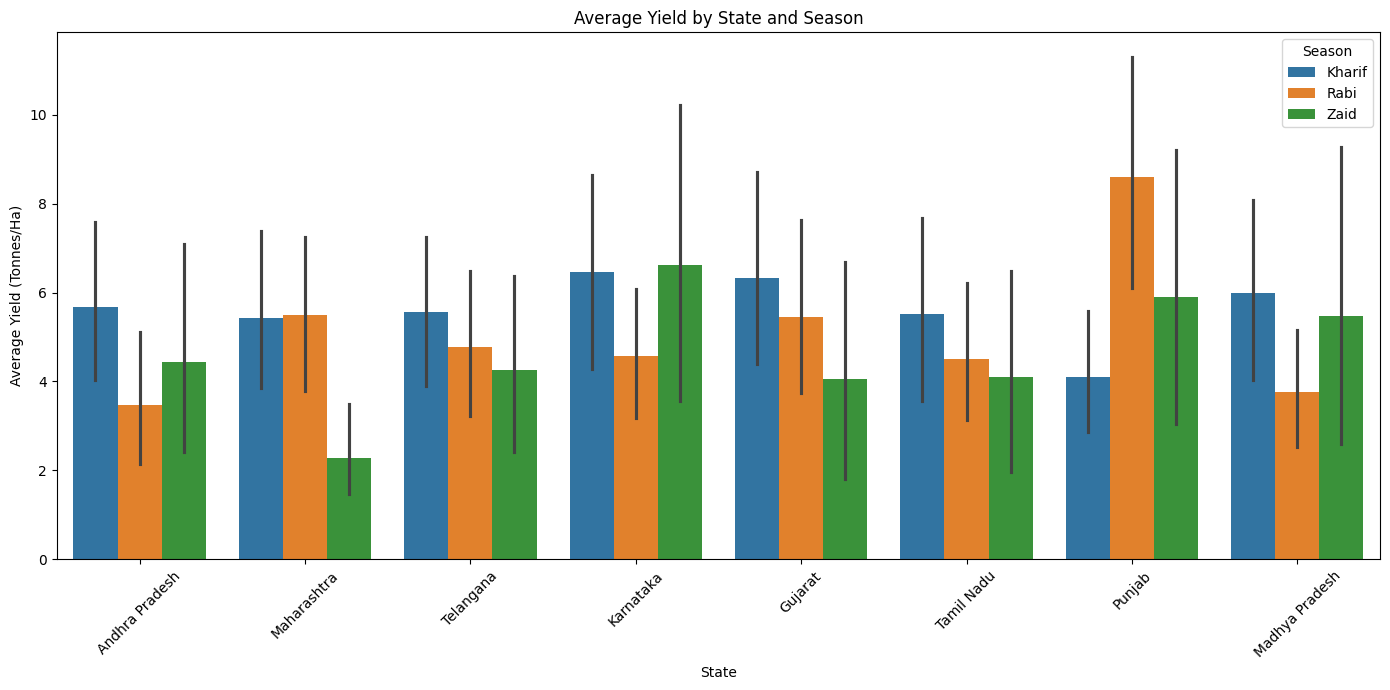

In [41]:
plt.figure(figsize=(14, 7))
sns.barplot(data=df,x='State',y='Yield_Tonnes_Ha',hue='Season',estimator='mean')
plt.title('Average Yield by State and Season')
plt.xlabel('State')
plt.ylabel('Average Yield (Tonnes/Ha)')
plt.xticks(rotation=45)
plt.legend(title='Season')
plt.tight_layout()
plt.show()

In [42]:
outlier_cols = ['Yield_Tonnes_Ha','Profit_INR','Water_Efficiency_t_per_1000m3']
for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) |(df[col] > upper_bound)]
    print(f"\n{col}")
    print("-" * 40)
    print("Lower Bound:", round(lower_bound, 2))
    print("Upper Bound:", round(upper_bound, 2))
    print("Number of Outliers:", len(outliers))
    print(outliers[['Farm_ID', 'State', 'Crop', 'Season', col]].sort_values(col))


Yield_Tonnes_Ha
----------------------------------------
Lower Bound: -1.62
Upper Bound: 5.5
Number of Outliers: 302
      Farm_ID           State       Crop  Season  Yield_Tonnes_Ha
1906  SF11907     Maharashtra      Maize  Kharif             5.59
1468  SF11469       Karnataka      Maize  Kharif             5.66
1526  SF11527  Madhya Pradesh       Rice  Kharif             5.67
1620  SF11621       Karnataka      Maize  Kharif             5.70
2318  SF12319       Telangana       Rice  Kharif             5.70
...       ...             ...        ...     ...              ...
3523  SF13524       Karnataka  Sugarcane  Kharif            91.46
1464  SF11465         Gujarat  Sugarcane  Kharif            91.98
3525  SF13526  Andhra Pradesh  Sugarcane    Rabi            93.13
3423  SF13424  Andhra Pradesh  Sugarcane  Kharif            95.79
1715  SF11716         Gujarat  Sugarcane  Kharif           101.44

[302 rows x 5 columns]

Profit_INR
----------------------------------------
Lower Bound: 

## Key Findings

- Kharif season showed the strongest overall performance in yield, production, profit, and water efficiency.
- Zaid season showed the weakest economic performance, with negative average profit and the lowest water efficiency.
- Environmental conditions varied considerably across seasons, especially rainfall, temperature, humidity, and soil moisture.
- Fertilizer and nutrient usage were relatively similar across seasons, so input quantity alone did not explain the seasonal differences.
- ANOVA showed a significant difference in profit across seasons, while the difference in yield was not statistically significant.
- Sugarcane showed the highest yield and profit among the crops across all seasons.
- Several crops, including Rice, Maize, and Wheat, showed negative profits despite having reasonable yields.
- Punjab had the highest average yield and profit among the states.
- Kharif was generally the most profitable season across states, while Zaid had several loss-making state-season combinations.
- Outlier analysis showed extreme values mainly because different crops have very different yield, profit, and water-efficiency scales.

# Recommendations

1. Seasonal crop planning should consider both profitability and resource efficiency rather than yield alone.

2. Zaid-season farming should receive greater attention to water management because it showed the highest average water usage and lowest water efficiency.

3. Crop-specific planning should be preferred because profitability varies considerably between crop-season combinations.

4. Loss-making crop-season combinations should be reviewed in terms of production costs, expected revenue, market price, and resource requirements before planting decisions.

5. Regional strategies should be adapted to local seasonal patterns because different states showed different performance trends.

6. Environmental indicators such as rainfall, soil moisture, and temperature should be considered alongside historical agricultural performance.

7. Unusual observations should be investigated for possible data-quality issues or genuine exceptional farm performance instead of being automatically removed.

# Conclusion

The analysis demonstrates that agricultural performance varies across seasons in terms of environmental conditions, resource usage, production, water efficiency, and economic outcomes. Kharif showed the strongest overall performance, while Zaid showed weaker economic performance and lower water efficiency.

However, the crop-wise and state-wise analyses also revealed important variations and exceptions. Therefore, agricultural planning should not rely only on season-level averages. Crop characteristics, regional conditions, resource requirements, and economic outcomes should also be considered.

The ANOVA results showed that seasonal differences in profit were statistically significant, whereas the observed differences in average yield were not statistically significant. Overall, the findings support data-driven, crop-specific and region-specific seasonal planning with particular attention to profitability and efficient water use.

# Project Questions – Summary

| Question | Main Finding |
|---|---|
| 1. How does agricultural performance vary across seasons? | Kharif generally performed best, while Zaid was weakest economically. |
| 2. What major seasonal patterns can be observed? | Kharif showed higher yield, production, revenue and water efficiency. |
| 3. Which characteristics change between seasons? | Rainfall, temperature, humidity, soil moisture, water use and economic outcomes vary across seasons. |
| 4. What differences exist between agricultural activities? | Crop performance and profitability vary considerably across crops and seasons. |
| 5. How does resource usage vary? | Water use varies more noticeably than nutrient and fertilizer inputs. |
| 6. Are environmental conditions related to performance? | Seasonal environmental differences are visible, but overall correlations with yield are weak. |
| 7. How do economic outcomes vary? | Kharif had the highest average profit and Zaid had negative average profit. |
| 8. Are patterns consistent across regions? | Many patterns are similar, but important state-level exceptions exist. |
| 9. Are there unusual patterns? | Yes, particularly high sugarcane values and unusual state-season combinations. |
| 10. What insights can be derived? | Season, crop and region should all be considered in agricultural planning. |
| 11. What conclusions can reasonably be drawn? | Profitability differs significantly by season, while yield differences were not statistically significant. |
| 12. How can findings support planning? | They can support crop selection, water management and region-specific seasonal planning. |